# KNN Regression, AQI Forecasting

k-nearest neighbors regression: predict aqi as the weighted average of the k most similar
training days (by feature distance). no training phase, just a lookup at inference time.

key considerations for this dataset:
- features must be scaled, distances depend on the units of each feature
- k controls the bias-variance tradeoff, small k = high variance, large k = high bias
- distance metric fixed to euclidean (L2); L1/L2 are both reasonable choices,
  but euclidean is the default and works well on normalized features
- **curse of dimensionality**, KNN degrades in high dimensions because
  distances become less meaningful as features grow. we have ~75 features, so we do a
  joint grid search over k AND pca dimensionality to find the best combination

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

from preprocessing import (
    load_and_prepare, impute, build_features,
    get_train_test, get_arrays, evaluate, save_results,
    AQI_LABELS,
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load and prepare data

In [146]:
df = load_and_prepare()
df = impute(df)
df, feature_cols = build_features(df)
train_df, test_df = get_train_test(df)
X_train, X_test, y_train_log, y_test_raw, y_test_log = get_arrays(train_df, test_df, feature_cols)

print(f'features: {len(feature_cols)}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

train: 19,750 rows | test: 5,100 rows | cutoff: 2019-12-01
features: 70
X_train: (19750, 70) | X_test: (5100, 70)


## 2. Scale features

KNN computes euclidean distances between feature vectors, so unscaled features
with large ranges (e.g. pm10 in hundreds vs is_weekend in {0,1}) will dominate
the distance calculation. standardscaler fixes this.

In [147]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## 3. Baseline: k=5, Full Features, No PCA

k=5 is the scikit-learn default; using all 70 raw features with no PCA is the naive approach.
this establishes a pre-tuning baseline to measure improvement from optimising k and applying PCA.

In [148]:
knn_base = KNeighborsRegressor(n_neighbors=5, weights='distance',
                                metric='euclidean', n_jobs=-1)
knn_base.fit(X_train_s, y_train_log)
base_preds = np.clip(np.expm1(knn_base.predict(X_test_s)), 0, None)

base_rmse = float(np.sqrt(mean_squared_error(y_test_raw, base_preds)))
base_mae  = float(np.mean(np.abs(y_test_raw - base_preds)))
base_r2   = float(1 - np.sum((y_test_raw - base_preds) ** 2) /
                      np.sum((y_test_raw - np.mean(y_test_raw)) ** 2))

print('Baseline (k=5, Euclidean, full features, no PCA):')
print(f'  RMSE = {base_rmse:.2f}')
print(f'  MAE  = {base_mae:.2f}')
print(f'  R²   = {base_r2:.3f}')

Baseline (k=5, Euclidean, full features, no PCA):
  RMSE = 45.22
  MAE  = 29.44
  R²   = 0.750


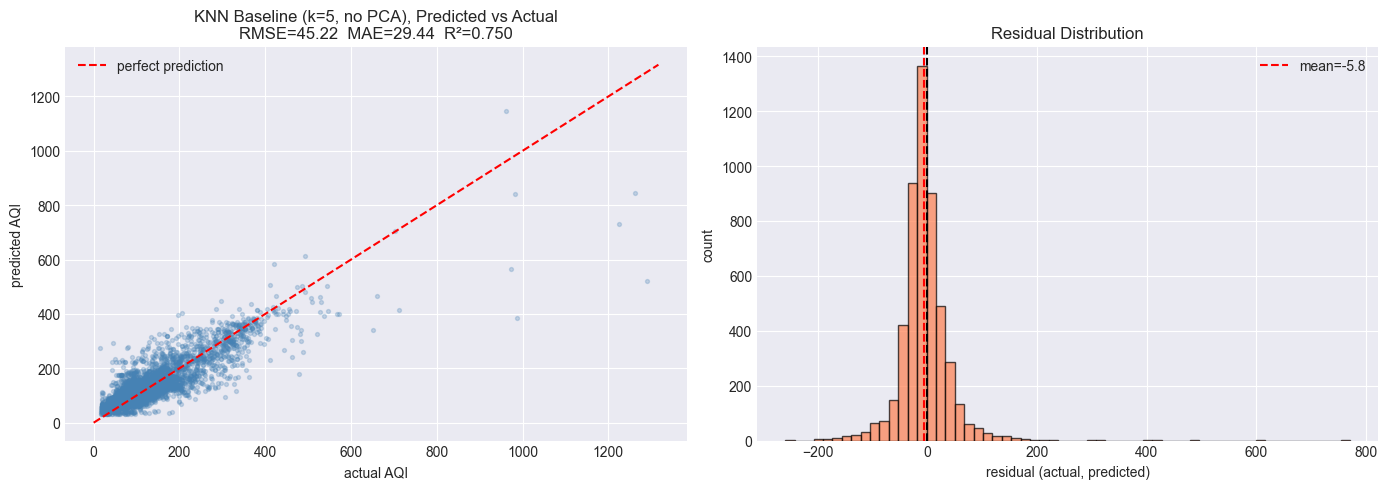

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
lim = max(y_test_raw.max(), base_preds.max()) * 1.02
axes[0].scatter(y_test_raw, base_preds, alpha=0.25, s=8, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='perfect prediction')
axes[0].set(xlabel='actual AQI', ylabel='predicted AQI',
            title=f'KNN Baseline (k=5, no PCA), Predicted vs Actual\nRMSE={base_rmse:.2f}  MAE={base_mae:.2f}  R²={base_r2:.3f}')
axes[0].legend()

# residual distribution
base_residuals = y_test_raw - base_preds
axes[1].hist(base_residuals, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].axvline(base_residuals.mean(), color='red', ls='--',
                label=f'mean={base_residuals.mean():.1f}')
axes[1].set(xlabel='residual (actual, predicted)', ylabel='count',
            title='Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Curse of Dimensionality and PCA

KNN performs poorly in high dimensions: distances between points become nearly equal as
dimensionality grows, so the "nearest" neighbor is barely closer than a random point.
we have ~75 features, which is high enough for this to matter.

one standard remedy is **PCA**, project the data into the top principal components that
capture most of the variance, reducing the effective dimensionality before computing distances.

components for 90% variance: 37
components for 95% variance: 45
original features:           70


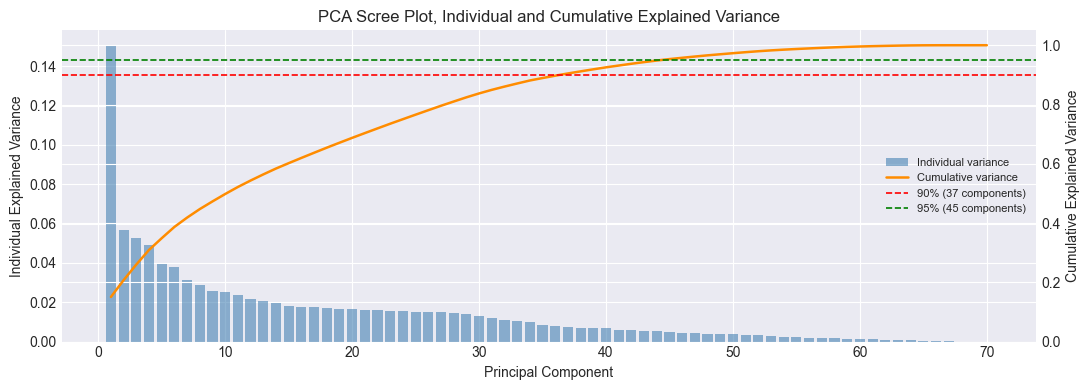

In [150]:
# scree plot, how many components needed to capture 90% / 95% variance?
pca_full = PCA().fit(X_train_s)
indiv    = pca_full.explained_variance_ratio_
cumvar   = np.cumsum(indiv)

n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
print(f'components for 90% variance: {n90}')
print(f'components for 95% variance: {n95}')
print(f'original features:           {X_train_s.shape[1]}')

fig, ax1 = plt.subplots(figsize=(11, 4))

# bars = individual proportion
components = np.arange(1, len(indiv) + 1)
ax1.bar(components, indiv, color='steelblue', alpha=0.6, label='Individual variance')
ax1.set(xlabel='Principal Component', ylabel='Individual Explained Variance')

# line = cumulative on a second y-axis
ax2 = ax1.twinx()
ax2.plot(components, cumvar, color='darkorange', linewidth=1.8, label='Cumulative variance')
ax2.axhline(0.90, color='red',    ls='--', lw=1.2, label=f'90% ({n90} components)')
ax2.axhline(0.95, color='green',  ls='--', lw=1.2, label=f'95% ({n95} components)')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

ax1.set_title('PCA Scree Plot, Individual and Cumulative Explained Variance')
plt.tight_layout()
plt.show()

In [151]:
# define pca dimensions to search, fine-grained in the low range where distances are most meaningful
# None = full features (~75d), integers = PCA reductions
pca_dims = [15, 17, 20, 25, 30, n90, n95, None]
print('feature spaces to search in joint grid:')
for d in pca_dims:
    print(f'  {"full (~75d)" if d is None else f"PCA {d}d"}')

feature spaces to search in joint grid:
  PCA 15d
  PCA 17d
  PCA 20d
  PCA 25d
  PCA 30d
  PCA 37d
  PCA 45d
  full (~75d)


## 5. Joint Grid Search: k × PCA Dimensions

we use a held-out validation set to tune hyperparameters. k is the key hyperparameter for
KNN, and reducing dimensionality via PCA is a standard fix for the curse of dimensionality.

we search k and pca together in one shot so the two decisions are consistent.
distance is fixed to euclidean (l2).

note: we use a time-ordered held-out window (oct,nov 2019) instead of random k-fold cv.
random k-fold would shuffle dates, letting training folds contain dates *after* validation
dates and leaking future data, not valid for time series.

In [152]:
val_cutoff = pd.Timestamp('2019-10-01')
tr_mask  = (train_df['date'] < val_cutoff).values
val_mask = (train_df['date'] >= val_cutoff).values

X_tr      = X_train_s[tr_mask]
y_tr      = y_train_log[tr_mask]
X_val     = X_train_s[val_mask]
y_val_raw = train_df.loc[val_mask, 'aqi'].values

print(f'tuning on {tr_mask.sum():,} train rows → {val_mask.sum():,} val rows')

tuning on 18,431 train rows → 1,319 val rows


In [153]:
k_range = [1, 2, 3, 5, 10, 15, 20, 25, 30]

grid = {}   # (space_label, k) -> val_rmse
best_rmse, best_k, best_n_pca = float('inf'), None, None

for n_comp in pca_dims:
    space_lbl = 'full' if n_comp is None else f'PCA {n_comp}d'
    if n_comp is not None:
        _pca = PCA(n_components=n_comp).fit(X_tr)
        Xtr_ = _pca.transform(X_tr)
        Xv_  = _pca.transform(X_val)
    else:
        Xtr_, Xv_ = X_tr, X_val

    for k in k_range:
        m    = KNeighborsRegressor(n_neighbors=k, weights='distance',
                                   metric='euclidean', n_jobs=-1)
        m.fit(Xtr_, y_tr)
        preds = np.clip(np.expm1(m.predict(Xv_)), 0, None)
        rmse  = float(np.sqrt(mean_squared_error(y_val_raw, preds)))
        grid[(space_lbl, k)] = rmse
        if rmse < best_rmse:
            best_rmse, best_k, best_n_pca = rmse, k, n_comp

best_space = 'full' if best_n_pca is None else f'PCA {best_n_pca}d'
print(f'best: k={best_k}, space={best_space}, val RMSE={best_rmse:.2f}')

best: k=15, space=PCA 15d, val RMSE=68.31


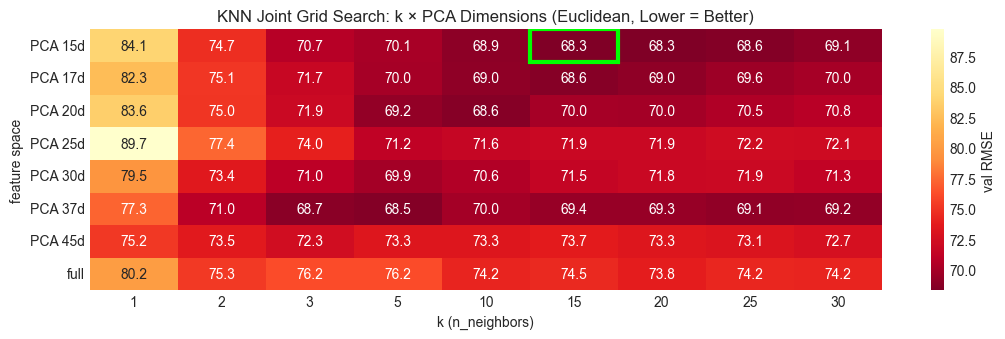

In [154]:
space_labels = ['full' if n is None else f'PCA {n}d' for n in pca_dims]
hm_data = pd.DataFrame(
    [[grid[(lbl, k)] for k in k_range] for lbl in space_labels],
    index=space_labels,
    columns=k_range,
)

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(hm_data, annot=True, fmt='.1f', cmap='YlOrRd_r', ax=ax,
            cbar_kws={'label': 'val RMSE'})
ax.set(xlabel='k (n_neighbors)', ylabel='feature space',
       title='KNN Joint Grid Search: k × PCA Dimensions (Euclidean, Lower = Better)')

# highlight best cell
best_row = space_labels.index(best_space)
best_col = k_range.index(best_k)
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
                            fill=False, edgecolor='lime', lw=3))
plt.tight_layout()
plt.show()

## 6. Fit Final Model on Full Training Set

In [155]:
# apply PCA to full train/test only if the grid search found PCA helps
if best_n_pca is not None:
    pca_final = PCA(n_components=best_n_pca).fit(X_train_s)
    X_tr_fit  = pca_final.transform(X_train_s)
    X_te_fit  = pca_final.transform(X_test_s)
    print(f'final: k={best_k}, euclidean, PCA {best_n_pca}d')
else:
    X_tr_fit, X_te_fit = X_train_s, X_test_s
    print(f'final: k={best_k}, euclidean, full features')

knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance',
                          metric='euclidean', n_jobs=-1)
knn.fit(X_tr_fit, y_train_log)

y_pred_log = knn.predict(X_te_fit)
y_pred_raw = np.clip(np.expm1(y_pred_log), 0, None)

pca_note = f', PCA {best_n_pca}d' if best_n_pca is not None else ''
result = evaluate(y_test_raw, y_pred_raw,
                  label=f'KNN (k={best_k}, euclidean{pca_note})')
save_results(result, 'knn')

final: k=15, euclidean, PCA 15d

──────────────────────────────────────────────────────
  KNN (k=15, euclidean, PCA 15d)
──────────────────────────────────────────────────────
  RMSE :    43.81
  MAE  :    26.86
  R²   :   0.7650
  MAE by AQI category:
              Good:   24.61  (n=535)
      Satisfactory:   19.93  (n=2,116)
          Moderate:   24.68  (n=1,746)
              Poor:   49.21  (n=406)
         Very Poor:   37.78  (n=236)
            Severe:  158.23  (n=61)
Saved → results/knn_metrics.json


## 7. Visualisations

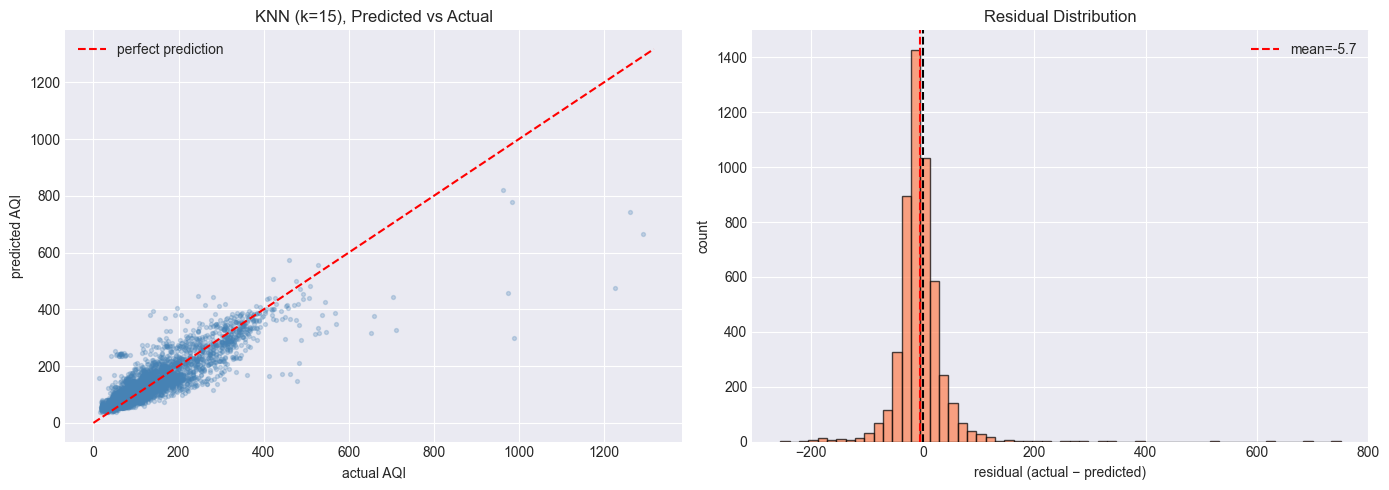

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
axes[0].scatter(y_test_raw, y_pred_raw, alpha=0.25, s=8, color='steelblue')
lim = max(y_test_raw.max(), y_pred_raw.max()) * 1.02
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='perfect prediction')
axes[0].set(xlabel='actual AQI', ylabel='predicted AQI',
            title=f'KNN (k={best_k}), Predicted vs Actual')
axes[0].legend()

# residual distribution
residuals = y_test_raw - y_pred_raw
axes[1].hist(residuals, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].axvline(residuals.mean(), color='red', ls='--',
                label=f'mean={residuals.mean():.1f}')
axes[1].set(xlabel='residual (actual − predicted)', ylabel='count',
            title='Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

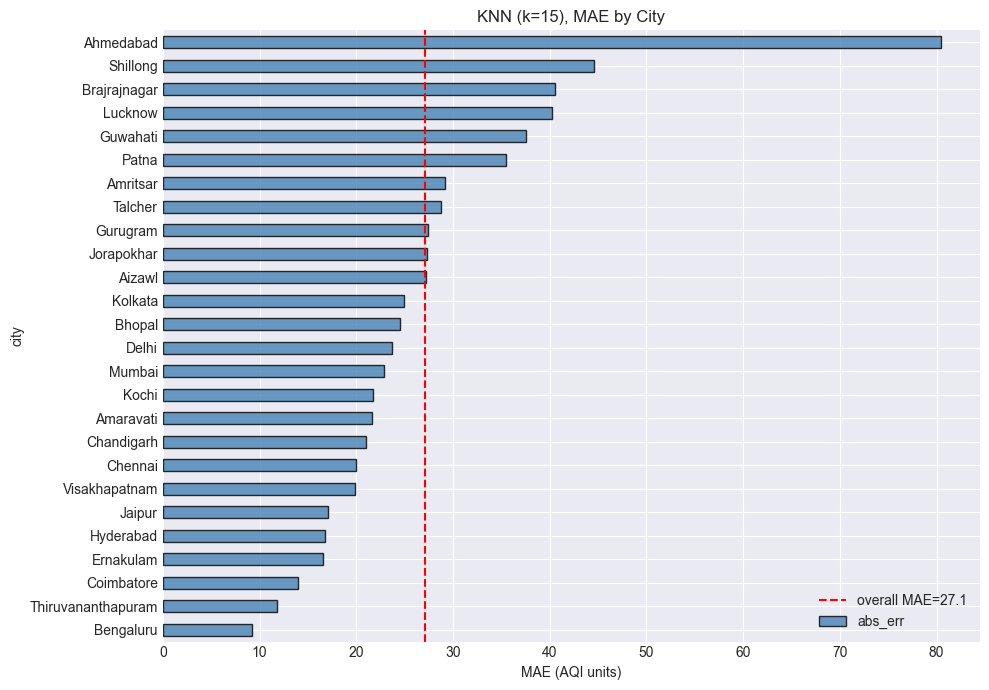

In [157]:
# per-city MAE, shows which cities the model struggles with
test_df = test_df.copy()
test_df['pred'] = y_pred_raw
test_df['abs_err'] = np.abs(test_df['aqi'] - test_df['pred'])

city_mae = (
    test_df.groupby('city')['abs_err']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
city_mae.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(city_mae.mean(), color='red', ls='--', label=f'overall MAE={city_mae.mean():.1f}')
ax.set(xlabel='MAE (AQI units)', title=f'KNN (k={best_k}), MAE by City')
ax.legend()
plt.tight_layout()
plt.show()

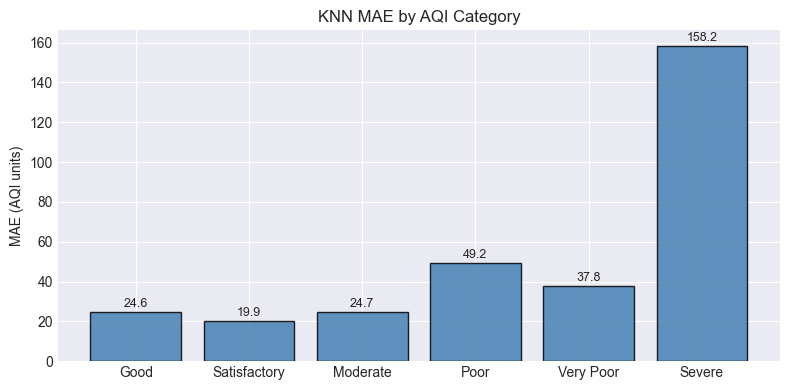

In [ ]:
# MAE by AQI category, shows where the model struggles most
cat_keys  = [f'MAE_{c}' for c in AQI_LABELS if f'MAE_{c}' in result]
cat_vals  = [result[k] for k in cat_keys]
cat_names = [k.replace('MAE_', '') for k in cat_keys]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cat_names, cat_vals, color='steelblue', edgecolor='black', alpha=0.85)

for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
            f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set(ylabel='MAE (AQI units)', title='KNN MAE by AQI Category')
plt.tight_layout()
plt.show()

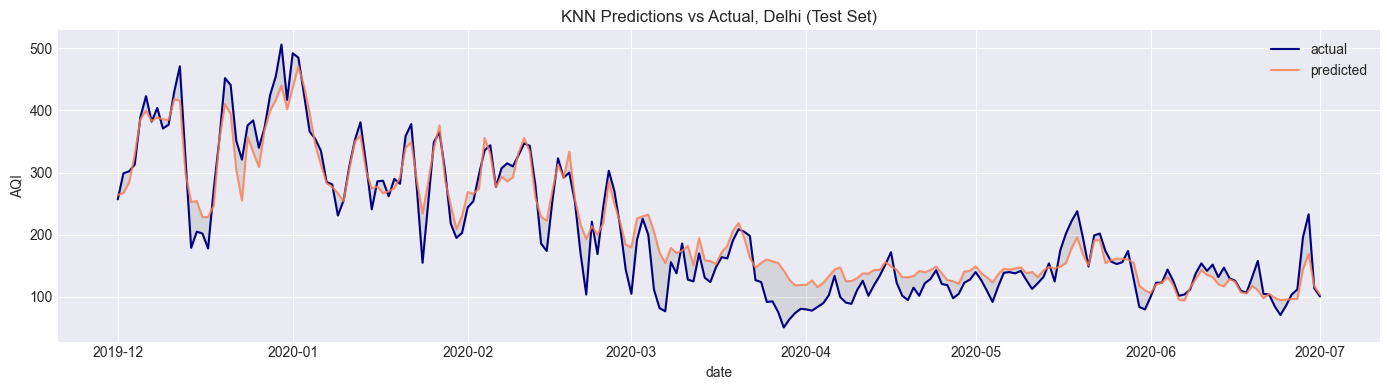

In [159]:
# time-series plot for a sample city, shows where the model over/under-predicts
sample_city = 'Delhi'
city_test = test_df[test_df['city'] == sample_city].sort_values('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(city_test['date'], city_test['aqi'],  label='actual',    lw=1.5, color='navy')
ax.plot(city_test['date'], city_test['pred'], label='predicted', lw=1.5, color='coral', alpha=0.8)
ax.fill_between(city_test['date'],
                city_test['aqi'], city_test['pred'],
                alpha=0.2, color='gray')
ax.set(xlabel='date', ylabel='AQI',
       title=f'KNN Predictions vs Actual, {sample_city} (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()